# Homework 03: Learning Curves and Training Workflow

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll again use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. 

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [17]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [18]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [19]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [20]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [21]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [43]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    '''layer_list format: width, activation_type,l2_lambda,dropout_rate'''
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [23]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [24]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Learning Curve for relu



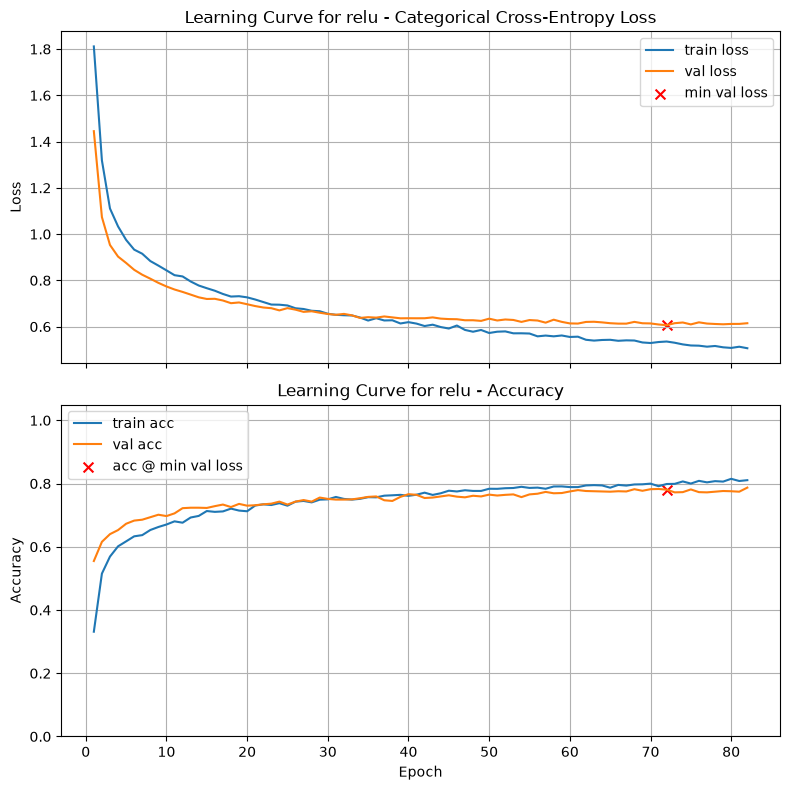

Final Training Loss:            0.5066
Final Training Accuracy:        0.8107
Final Validation Loss:          0.6147
Final Validation Accuracy:      0.7871
Minimum Validation Loss:        0.6063 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7807

Test Loss: 0.6219
Test Accuracy: 0.7700

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:17

Learning Curve for sigmoid



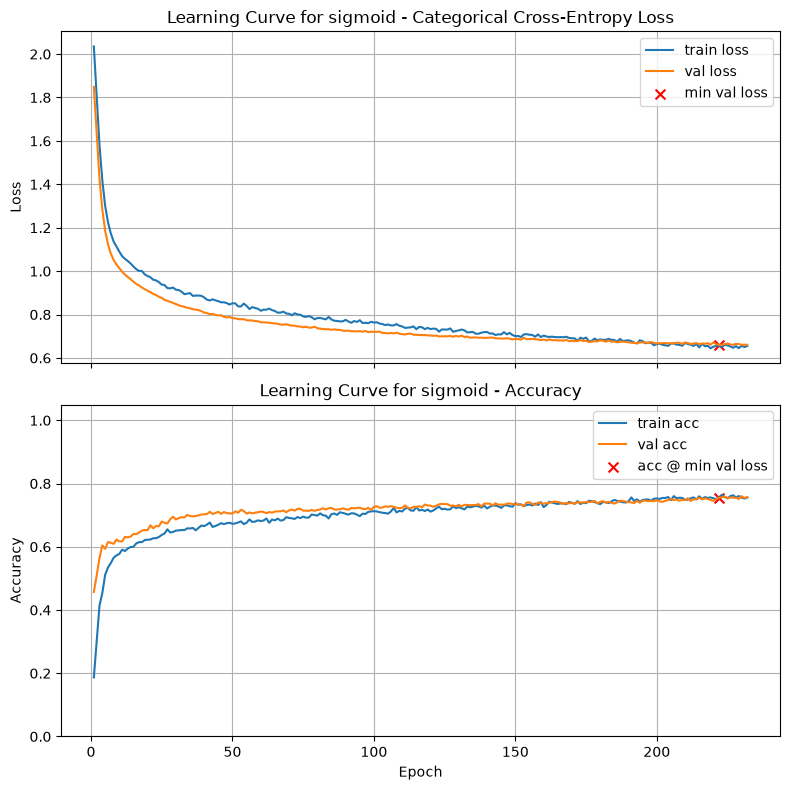

Final Training Loss:            0.6556
Final Training Accuracy:        0.7560
Final Validation Loss:          0.6607
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.6606 (Epoch 222)
Validation Accuracy @ Min Loss: 0.7550

Test Loss: 0.6886
Test Accuracy: 0.7350

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:54

Learning Curve for tanh



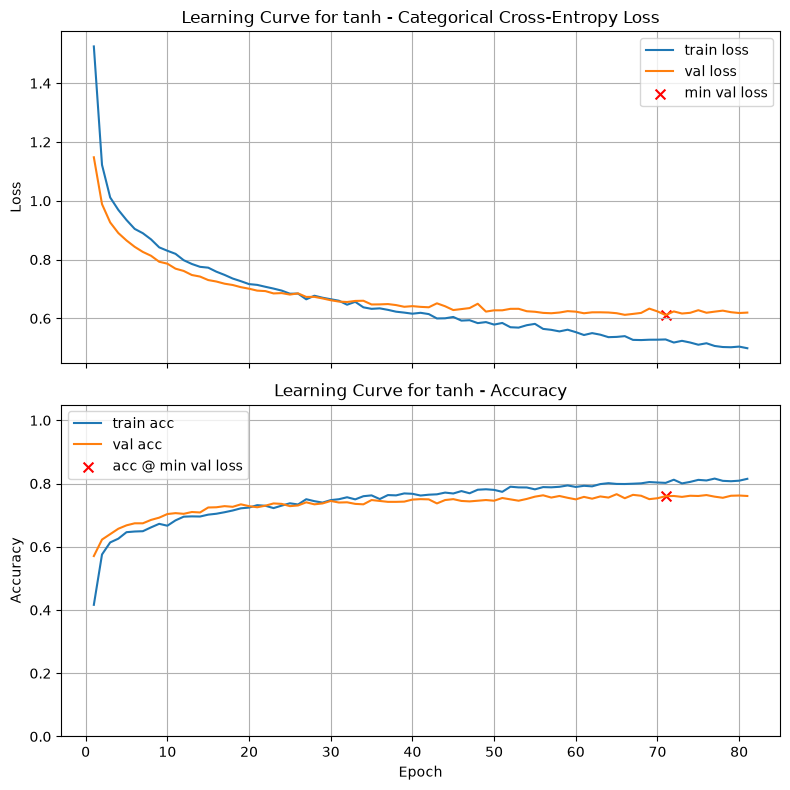

Final Training Loss:            0.4987
Final Training Accuracy:        0.8150
Final Validation Loss:          0.6199
Final Validation Accuracy:      0.7607
Minimum Validation Loss:        0.6114 (Epoch 71)
Validation Accuracy @ Min Loss: 0.7600

Test Loss: 0.6439
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:25


In [30]:
# Model with early stopping 
results_P1 = []
p1_models = []
for activation in ['relu','sigmoid','tanh']:
    model_baseline = build_model(X_train.shape[1], [ (64,activation,0.0,0.0), (32,activation,0.001,0.3)], n_classes)
    history = train_and_test(model_baseline,title=f"Learning Curve for {activation}",return_history=True)
    results_P1.append(history.history['val_accuracy'])
    p1_models.append(history)


### Graded Questions

In [10]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 0             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [11]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 0


In [28]:
# Set a1b to the validation accuracy found by this best activation function

a1b = max(results_P1[a1a])             # Replace 0.0 with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7786


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



Learning Curve for 0.001



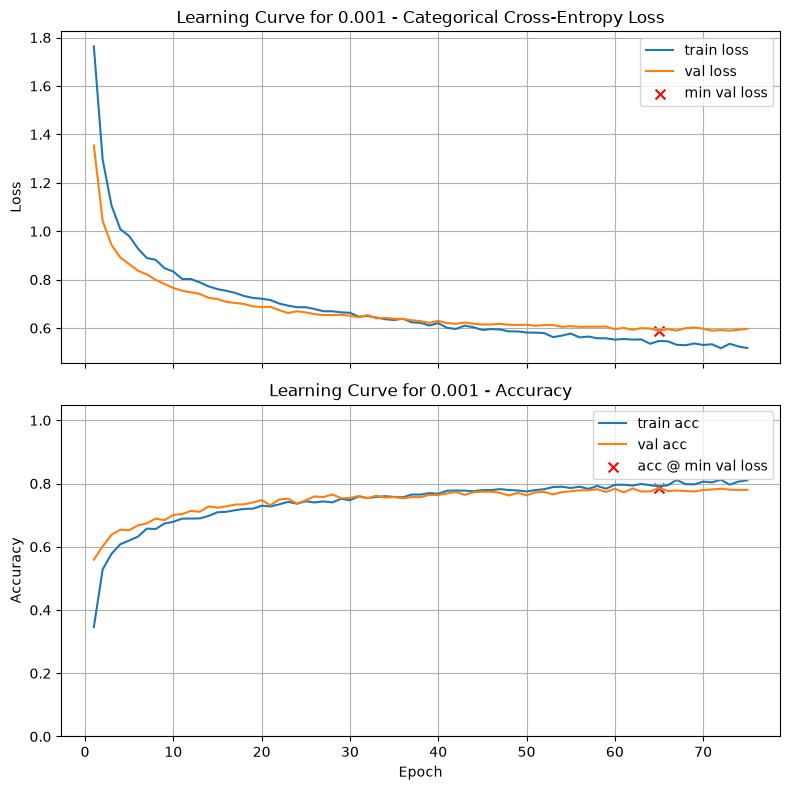

Final Training Loss:            0.5176
Final Training Accuracy:        0.8102
Final Validation Loss:          0.5971
Final Validation Accuracy:      0.7800
Minimum Validation Loss:        0.5883 (Epoch 65)
Validation Accuracy @ Min Loss: 0.7857

Test Loss: 0.6366
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:16

Learning Curve for 0.0005



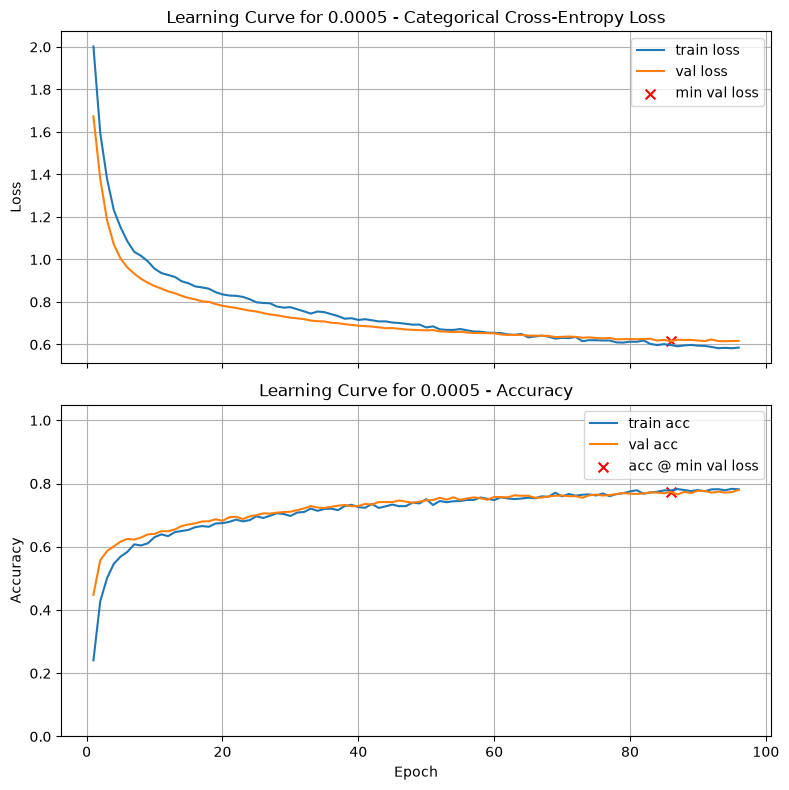

Final Training Loss:            0.5854
Final Training Accuracy:        0.7819
Final Validation Loss:          0.6171
Final Validation Accuracy:      0.7800
Minimum Validation Loss:        0.6152 (Epoch 86)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.6526
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:20

Learning Curve for 0.0001



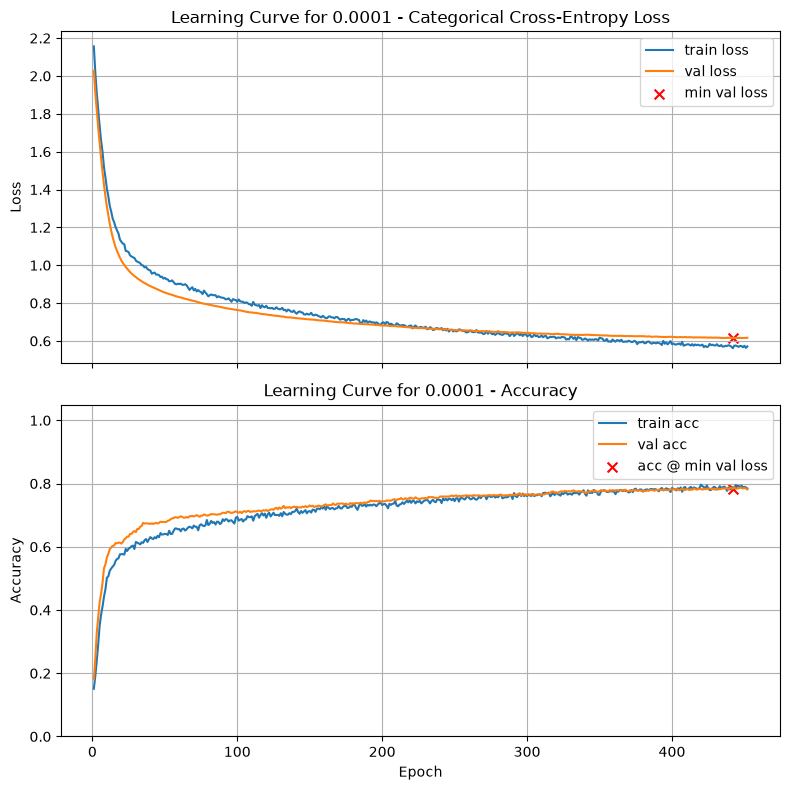

Final Training Loss:            0.5711
Final Training Accuracy:        0.7845
Final Validation Loss:          0.6169
Final Validation Accuracy:      0.7814
Minimum Validation Loss:        0.6147 (Epoch 442)
Validation Accuracy @ Min Loss: 0.7836

Test Loss: 0.6364
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:01:29

Learning Curve for 5e-05



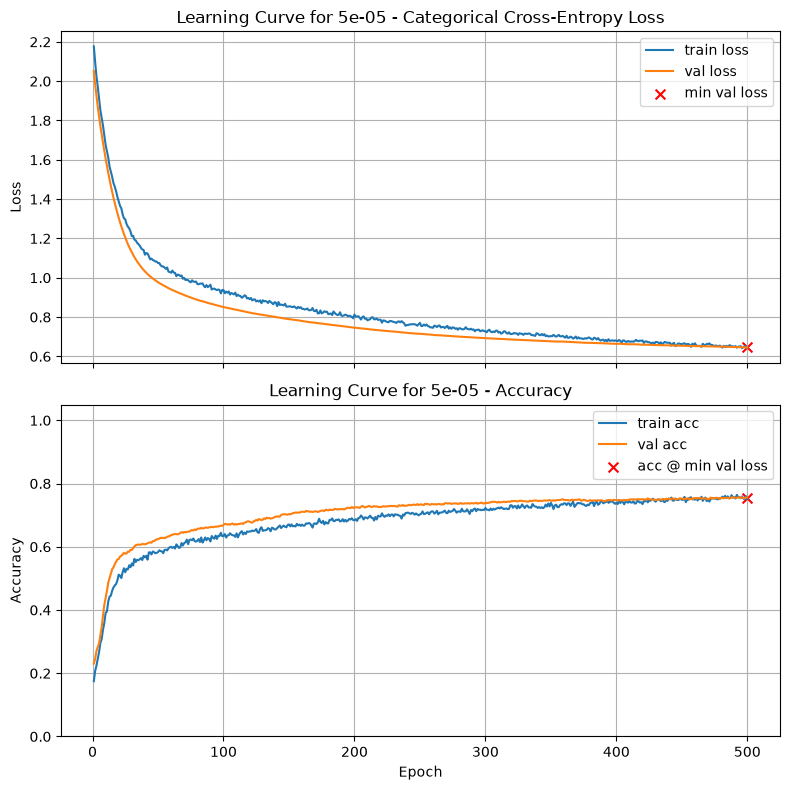

Final Training Loss:            0.6438
Final Training Accuracy:        0.7510
Final Validation Loss:          0.6454
Final Validation Accuracy:      0.7557
Minimum Validation Loss:        0.6454 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7557

Test Loss: 0.6794
Test Accuracy: 0.7357

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:01:38

Learning Curve for 1e-05



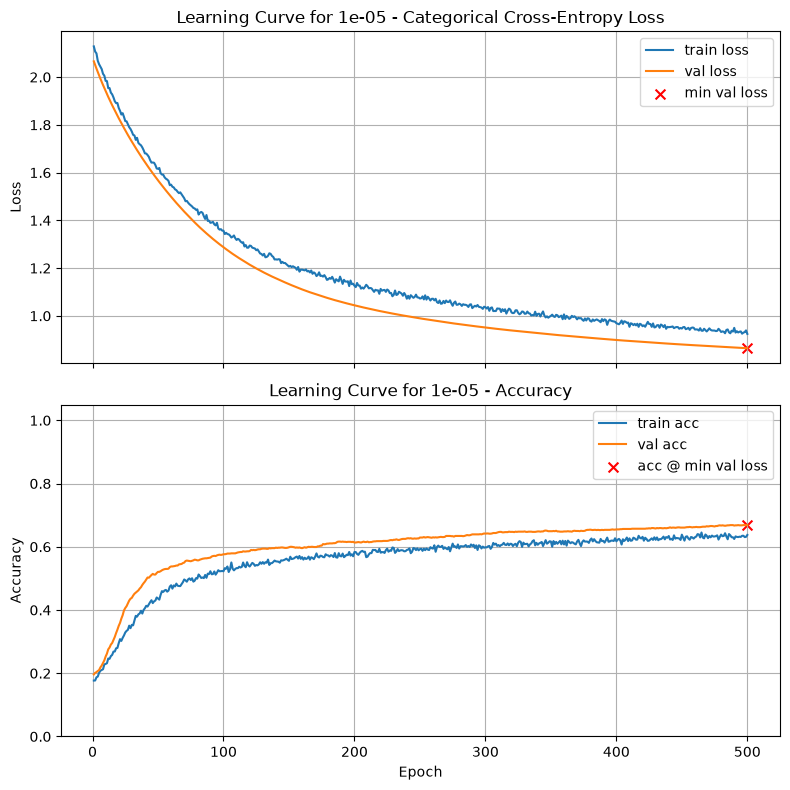

Final Training Loss:            0.9244
Final Training Accuracy:        0.6374
Final Validation Loss:          0.8644
Final Validation Accuracy:      0.6686
Minimum Validation Loss:        0.8644 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6686

Test Loss: 0.8690
Test Accuracy: 0.6750

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:01:37


In [31]:
# Model with early stopping 
results_P2 = []
p2_models = []
for rate in [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]:
    model_baseline = build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes)
    history = train_and_test(model_baseline,title=f"Learning Curve for {rate}",lr_schedule=rate,return_history=True)
    results_P2.append(history.history['val_accuracy'])
    p2_models.append(history)



In [36]:
p2_models
p2_results = dict(zip([1e-3, 5e-4, 1e-4, 5e-5, 1e-5],[max(x) for x in results_P2]))
p2_results

{0.001: 0.7857142686843872,
 0.0005: 0.7799999713897705,
 0.0001: 0.7878571152687073,
 5e-05: 0.756428599357605,
 1e-05: 0.668571412563324}

#### Graded Questions

In [37]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = max(p2_results)          # Replace 0.0 with your answer

In [38]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.001000


In [41]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = p2_results[a2a]                         # Replace 0.0 with your answer

In [42]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7857


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Learning Curve for 0.0 by 0.0



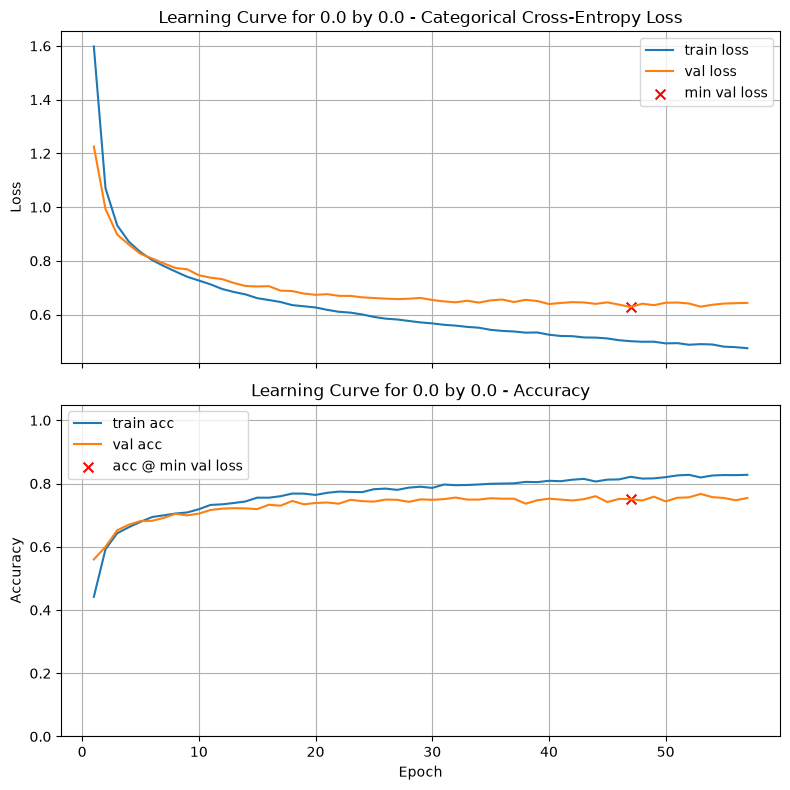

Final Training Loss:            0.4748
Final Training Accuracy:        0.8276
Final Validation Loss:          0.6436
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.6283 (Epoch 47)
Validation Accuracy @ Min Loss: 0.7507

Test Loss: 0.6532
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:13

Learning Curve for 0.0 by 0.1



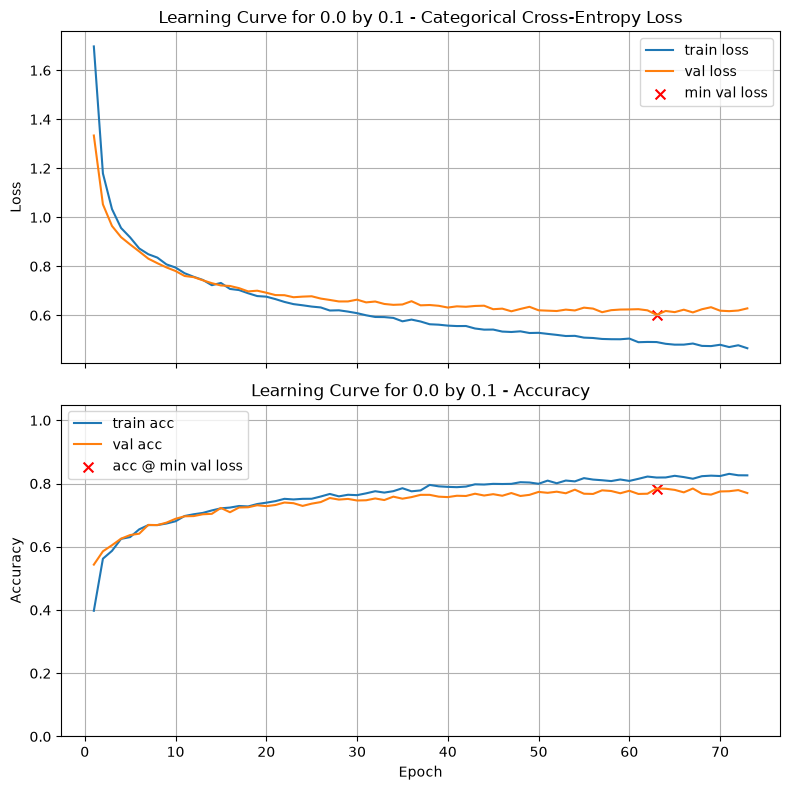

Final Training Loss:            0.4655
Final Training Accuracy:        0.8260
Final Validation Loss:          0.6282
Final Validation Accuracy:      0.7700
Minimum Validation Loss:        0.6017 (Epoch 63)
Validation Accuracy @ Min Loss: 0.7843

Test Loss: 0.6204
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:15

Learning Curve for 0.0 by 0.2



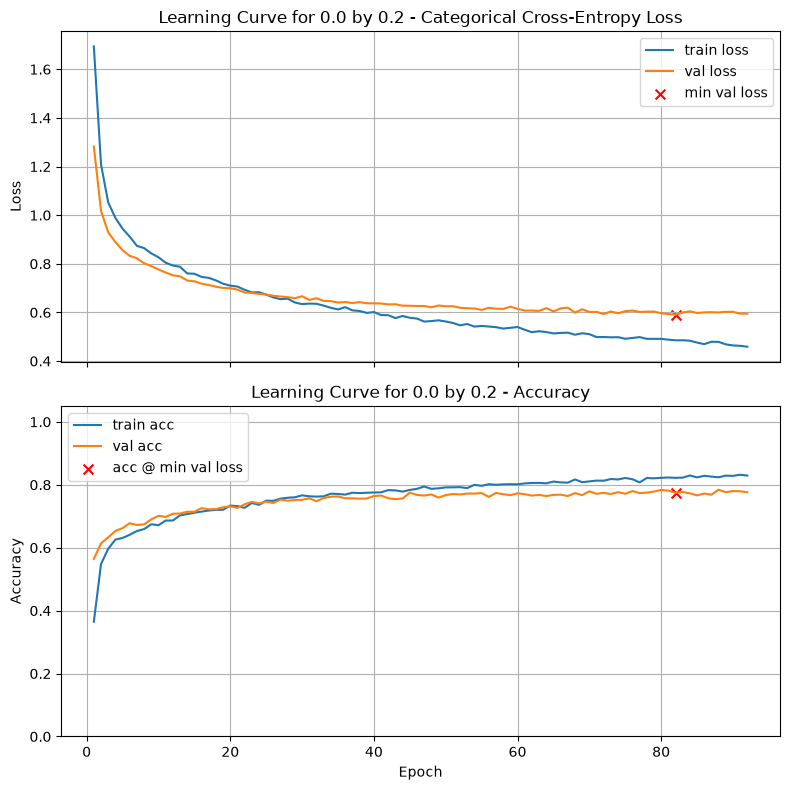

Final Training Loss:            0.4591
Final Training Accuracy:        0.8293
Final Validation Loss:          0.5952
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.5908 (Epoch 82)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.5961
Test Accuracy: 0.7686

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:19

Learning Curve for 0.0 by 0.30000000000000004



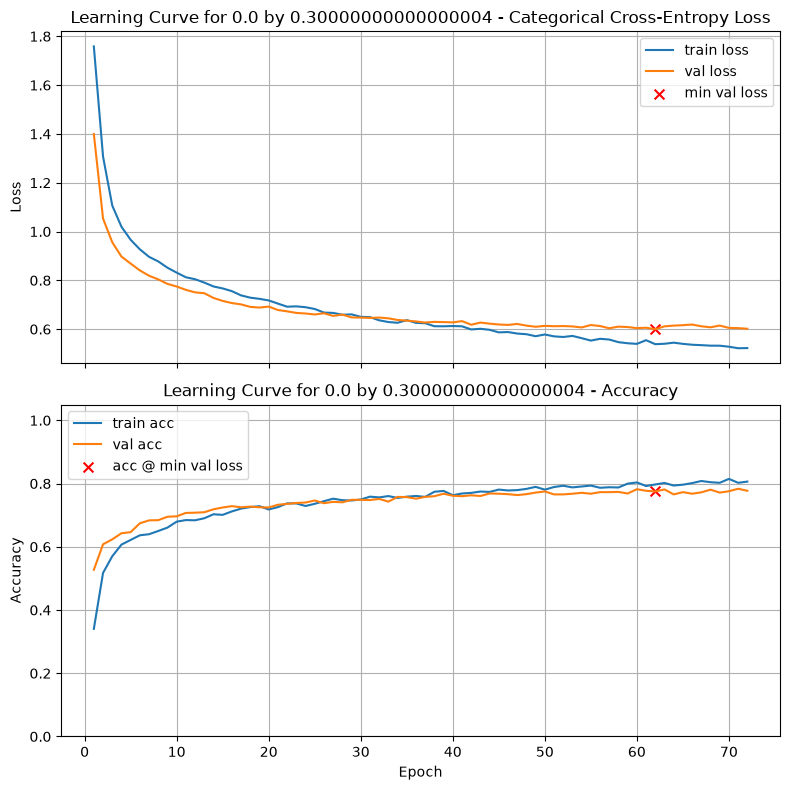

Final Training Loss:            0.5225
Final Training Accuracy:        0.8062
Final Validation Loss:          0.6017
Final Validation Accuracy:      0.7771
Minimum Validation Loss:        0.5996 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.6391
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:00:15

Learning Curve for 0.0 by 0.4



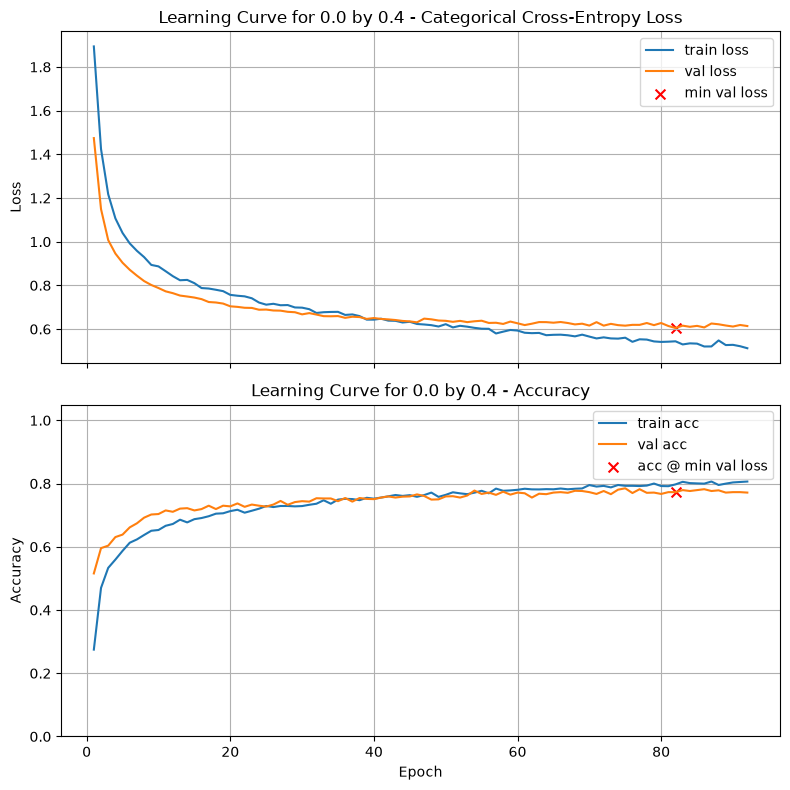

Final Training Loss:            0.5124
Final Training Accuracy:        0.8064
Final Validation Loss:          0.6140
Final Validation Accuracy:      0.7714
Minimum Validation Loss:        0.6051 (Epoch 82)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6260
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:19

Learning Curve for 0.1 by 0.0



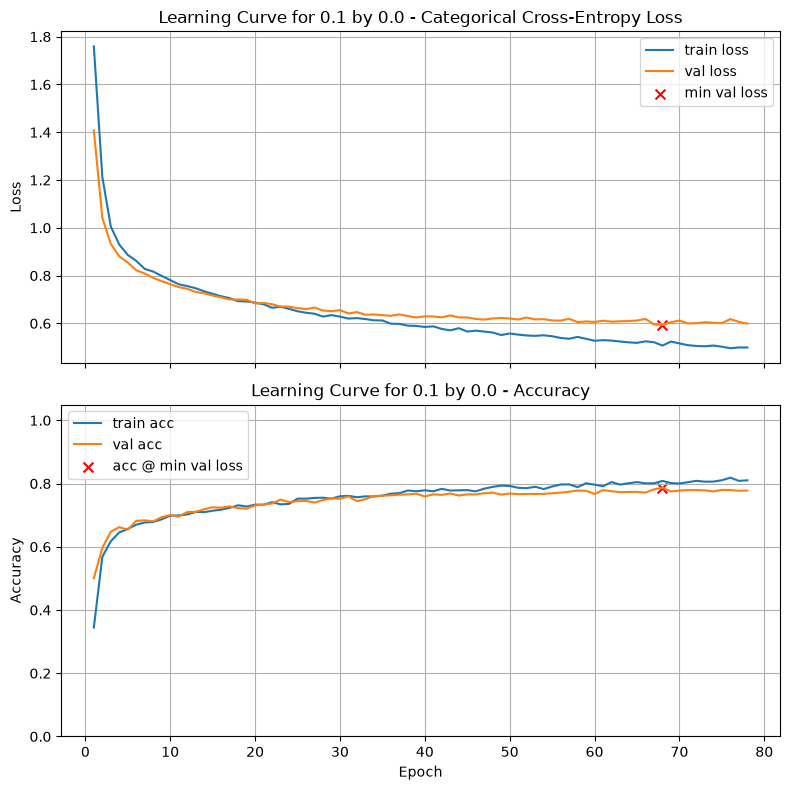

Final Training Loss:            0.4989
Final Training Accuracy:        0.8102
Final Validation Loss:          0.5988
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5928 (Epoch 68)
Validation Accuracy @ Min Loss: 0.7871

Test Loss: 0.6073
Test Accuracy: 0.7700

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:17

Learning Curve for 0.1 by 0.1



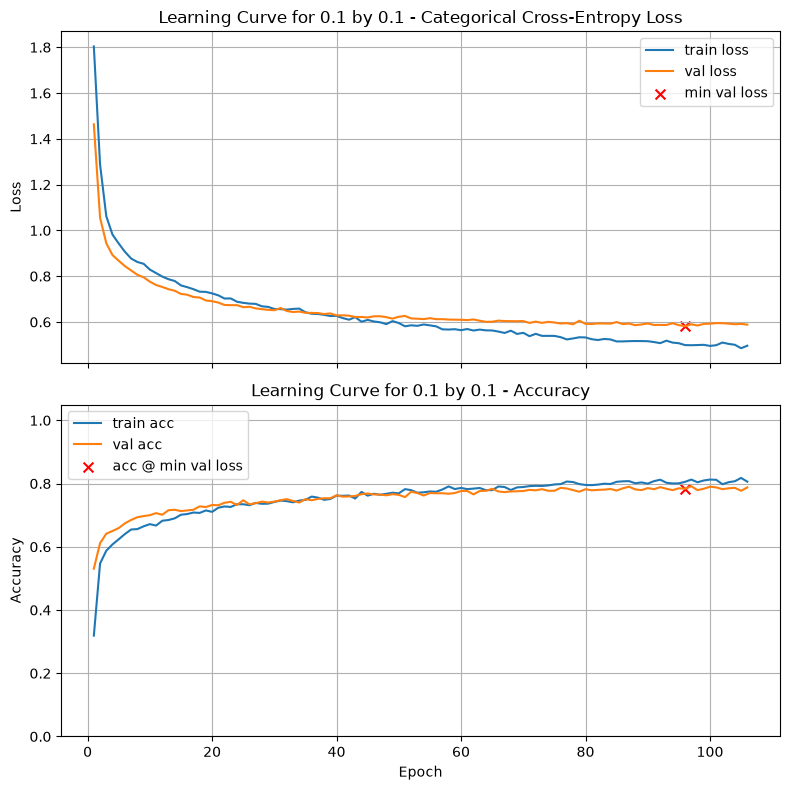

Final Training Loss:            0.4964
Final Training Accuracy:        0.8060
Final Validation Loss:          0.5884
Final Validation Accuracy:      0.7879
Minimum Validation Loss:        0.5813 (Epoch 96)
Validation Accuracy @ Min Loss: 0.7836

Test Loss: 0.6181
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:23

Learning Curve for 0.1 by 0.2



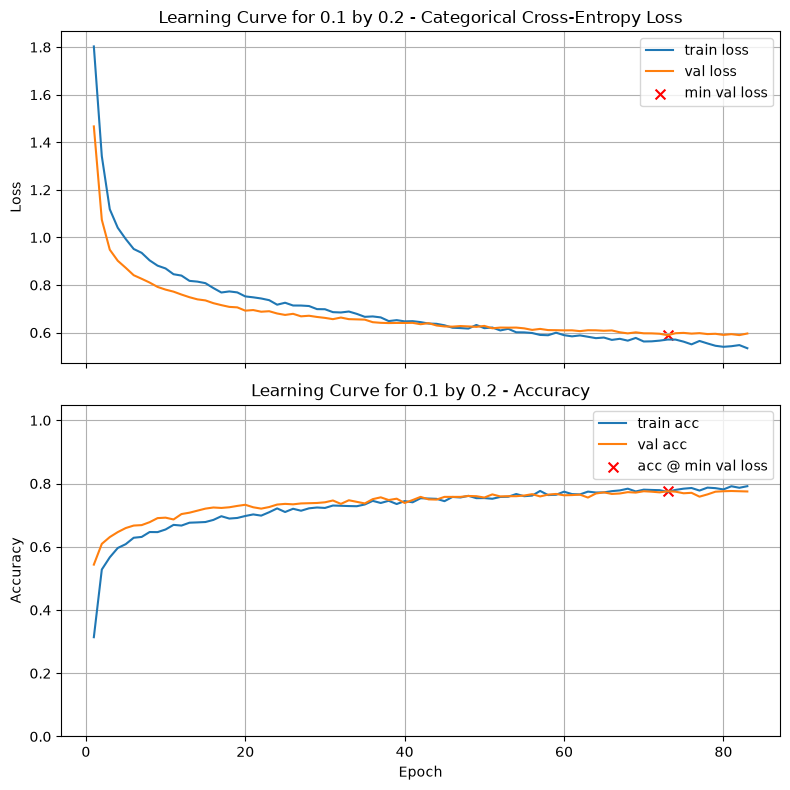

Final Training Loss:            0.5344
Final Training Accuracy:        0.7917
Final Validation Loss:          0.5962
Final Validation Accuracy:      0.7750
Minimum Validation Loss:        0.5892 (Epoch 73)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.6136
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:18

Learning Curve for 0.1 by 0.30000000000000004



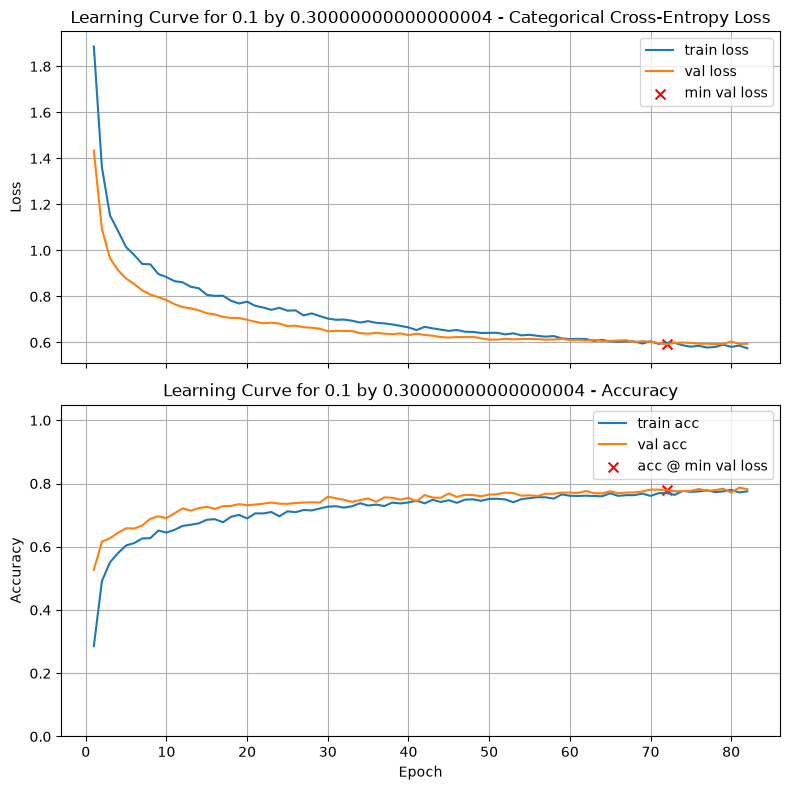

Final Training Loss:            0.5749
Final Training Accuracy:        0.7755
Final Validation Loss:          0.5946
Final Validation Accuracy:      0.7821
Minimum Validation Loss:        0.5920 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7793

Test Loss: 0.6313
Test Accuracy: 0.7571

Validation-Test Gap (accuracy): 0.022143

Execution Time: 00:00:18

Learning Curve for 0.1 by 0.4



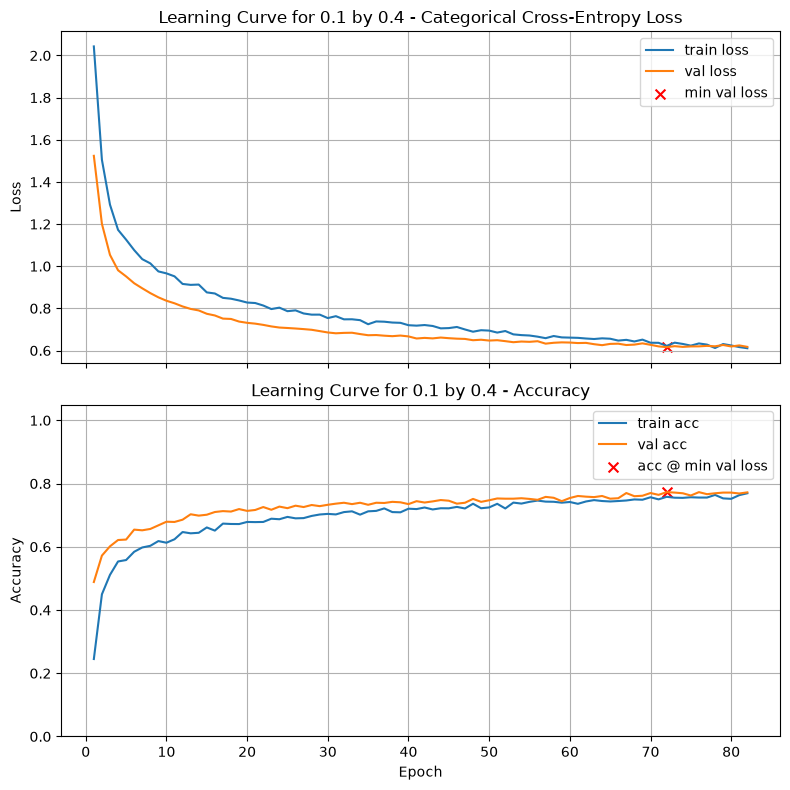

Final Training Loss:            0.6108
Final Training Accuracy:        0.7693
Final Validation Loss:          0.6173
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.6160 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6493
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:18

Learning Curve for 0.2 by 0.0



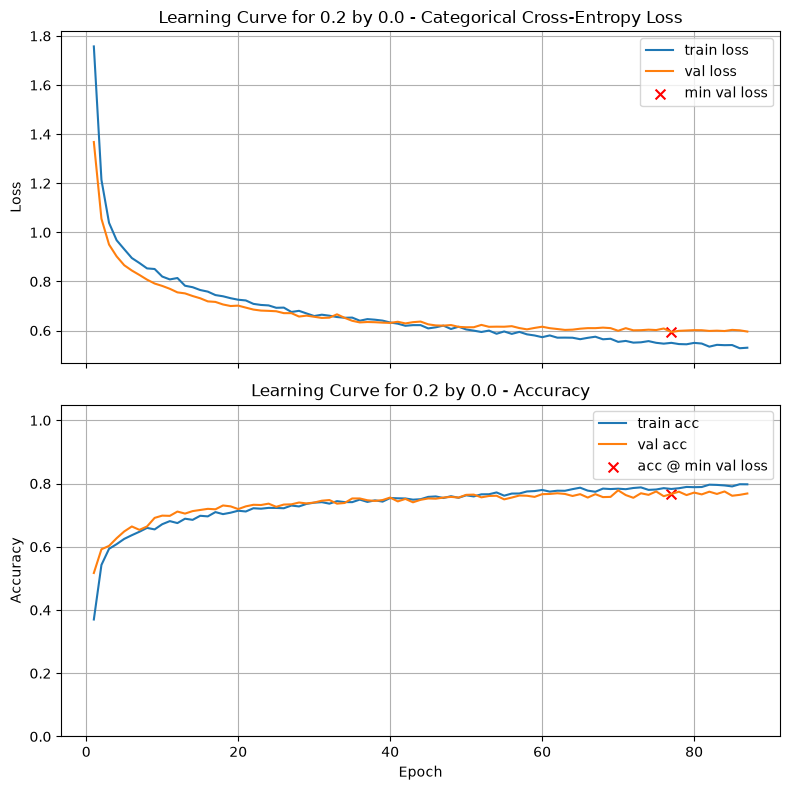

Final Training Loss:            0.5301
Final Training Accuracy:        0.7976
Final Validation Loss:          0.5960
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.5941 (Epoch 77)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6216
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:00:18

Learning Curve for 0.2 by 0.1



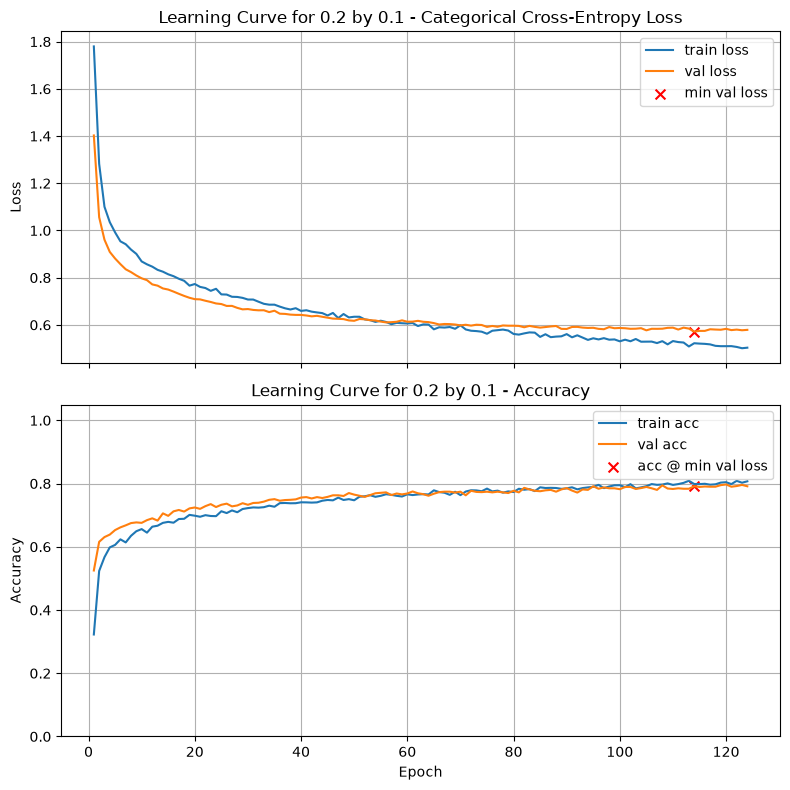

Final Training Loss:            0.5034
Final Training Accuracy:        0.8071
Final Validation Loss:          0.5790
Final Validation Accuracy:      0.7914
Minimum Validation Loss:        0.5717 (Epoch 114)
Validation Accuracy @ Min Loss: 0.7914

Test Loss: 0.5928
Test Accuracy: 0.7821

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:26

Learning Curve for 0.2 by 0.2



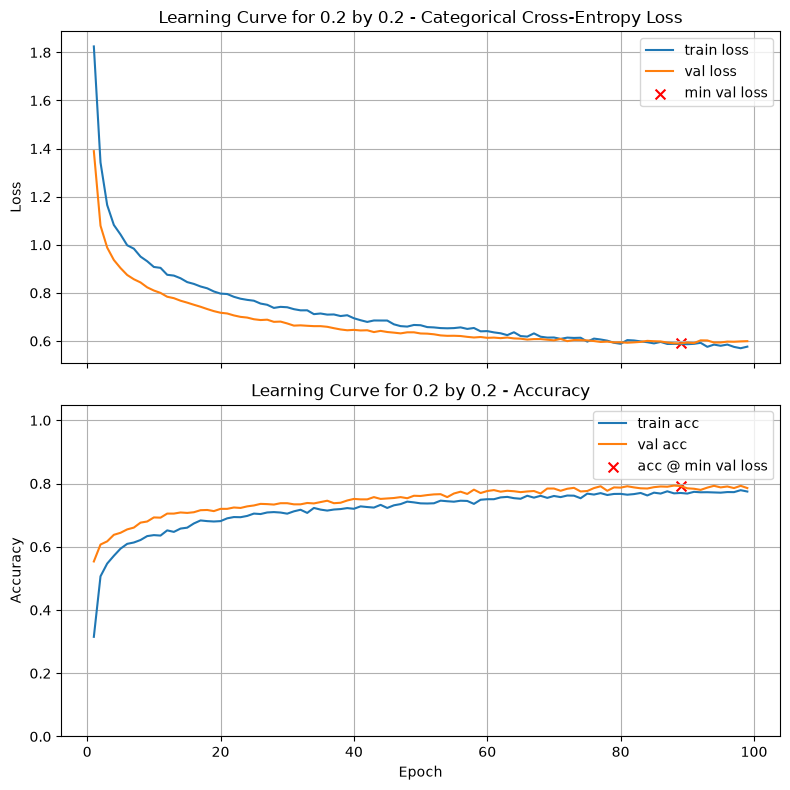

Final Training Loss:            0.5766
Final Training Accuracy:        0.7748
Final Validation Loss:          0.5994
Final Validation Accuracy:      0.7857
Minimum Validation Loss:        0.5901 (Epoch 89)
Validation Accuracy @ Min Loss: 0.7921

Test Loss: 0.6181
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.026429

Execution Time: 00:00:21

Learning Curve for 0.2 by 0.30000000000000004



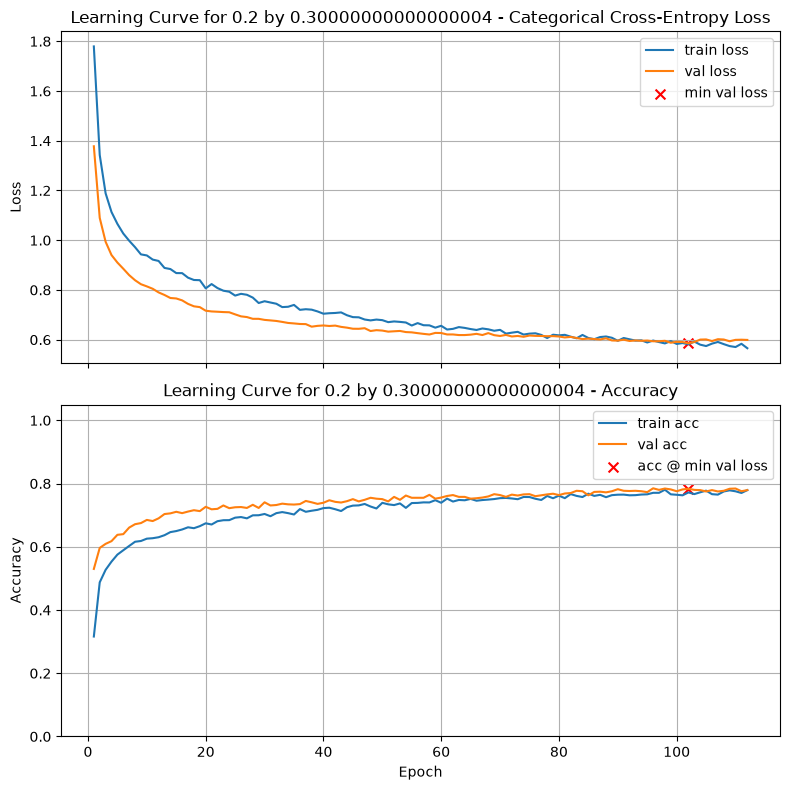

Final Training Loss:            0.5657
Final Training Accuracy:        0.7793
Final Validation Loss:          0.5991
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5855 (Epoch 102)
Validation Accuracy @ Min Loss: 0.7836

Test Loss: 0.6279
Test Accuracy: 0.7714

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:25

Learning Curve for 0.2 by 0.4



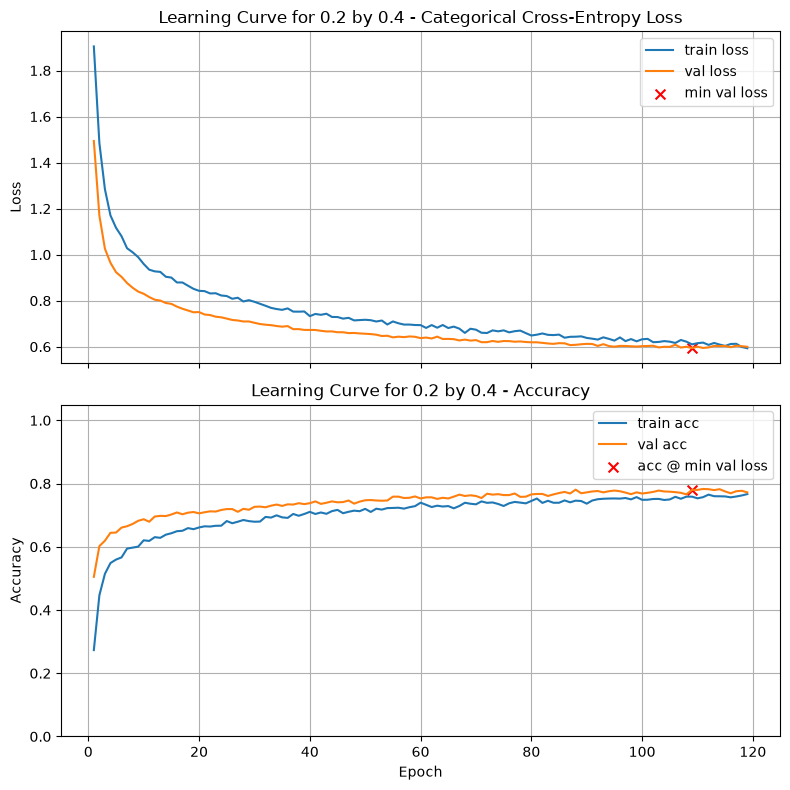

Final Training Loss:            0.5935
Final Training Accuracy:        0.7667
Final Validation Loss:          0.5996
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5941 (Epoch 109)
Validation Accuracy @ Min Loss: 0.7800

Test Loss: 0.6263
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.027857

Execution Time: 00:00:25

Learning Curve for 0.30000000000000004 by 0.0



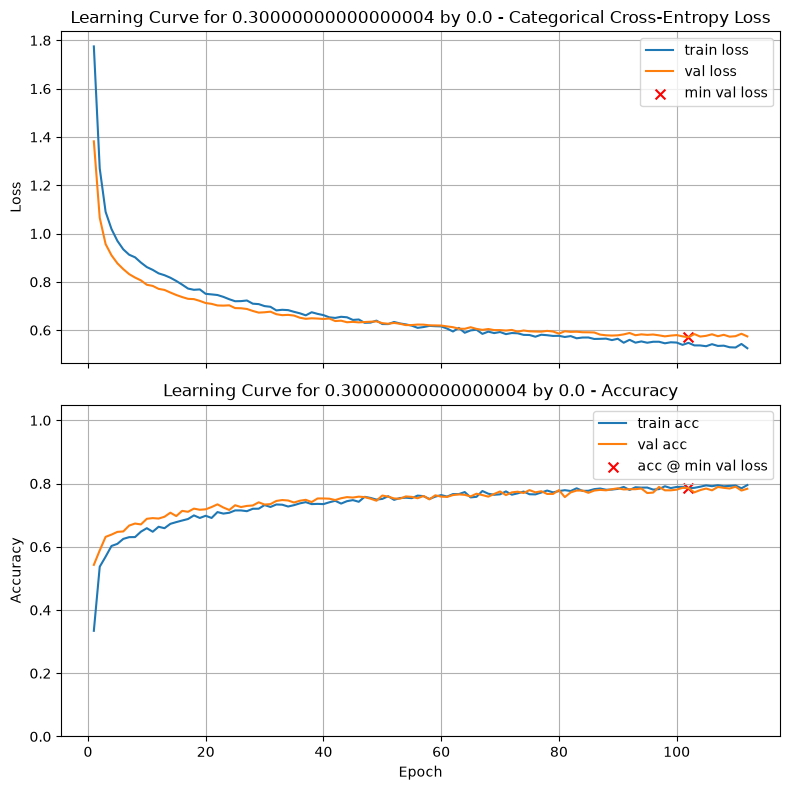

Final Training Loss:            0.5253
Final Training Accuracy:        0.7952
Final Validation Loss:          0.5743
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5707 (Epoch 102)
Validation Accuracy @ Min Loss: 0.7857

Test Loss: 0.6048
Test Accuracy: 0.7671

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:23

Learning Curve for 0.30000000000000004 by 0.1



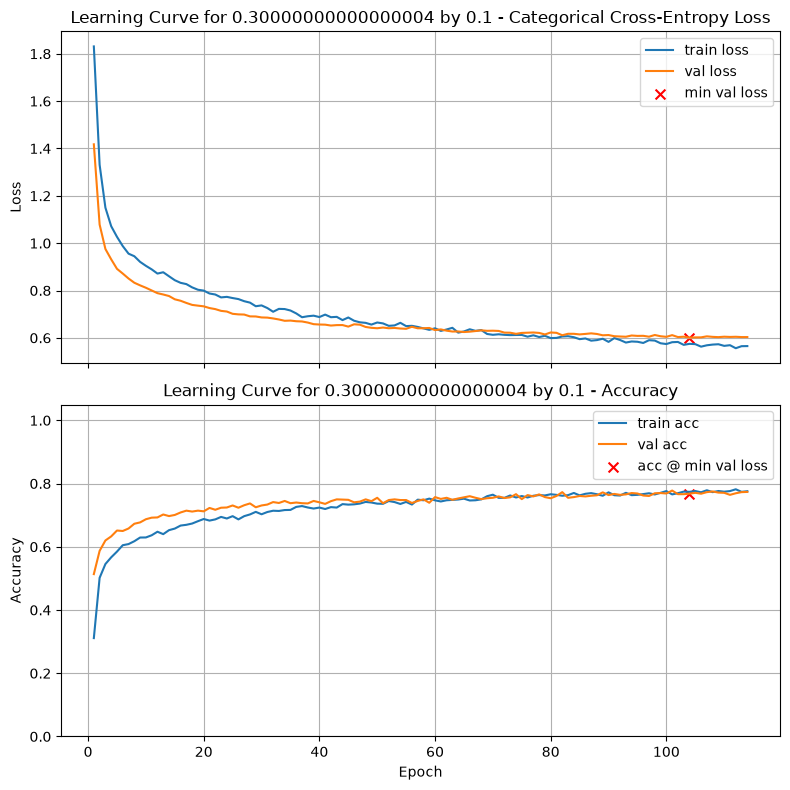

Final Training Loss:            0.5653
Final Training Accuracy:        0.7757
Final Validation Loss:          0.6034
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.6014 (Epoch 104)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6158
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:25

Learning Curve for 0.30000000000000004 by 0.2



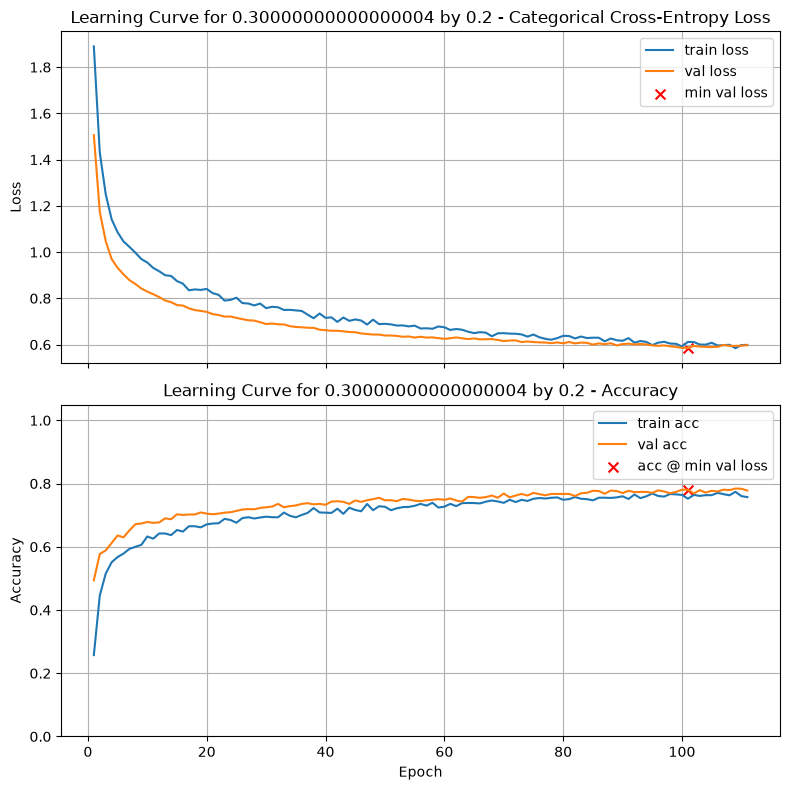

Final Training Loss:            0.5985
Final Training Accuracy:        0.7571
Final Validation Loss:          0.5974
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5854 (Epoch 101)
Validation Accuracy @ Min Loss: 0.7807

Test Loss: 0.6094
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:00:24

Learning Curve for 0.30000000000000004 by 0.30000000000000004



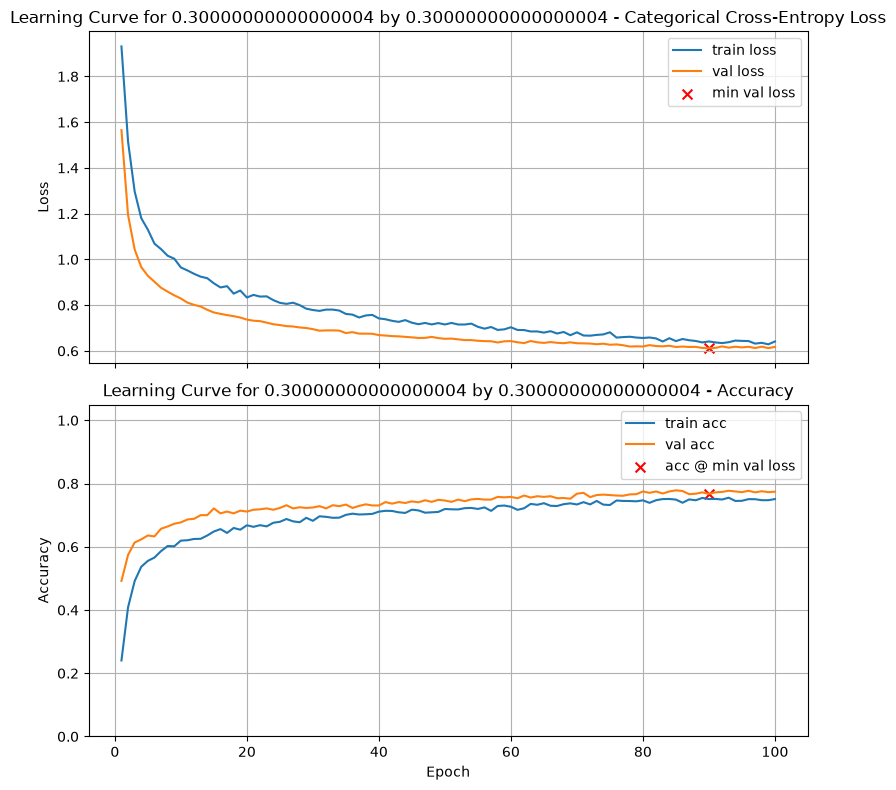

Final Training Loss:            0.6411
Final Training Accuracy:        0.7510
Final Validation Loss:          0.6173
Final Validation Accuracy:      0.7743
Minimum Validation Loss:        0.6116 (Epoch 90)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6357
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:00:22

Learning Curve for 0.30000000000000004 by 0.4



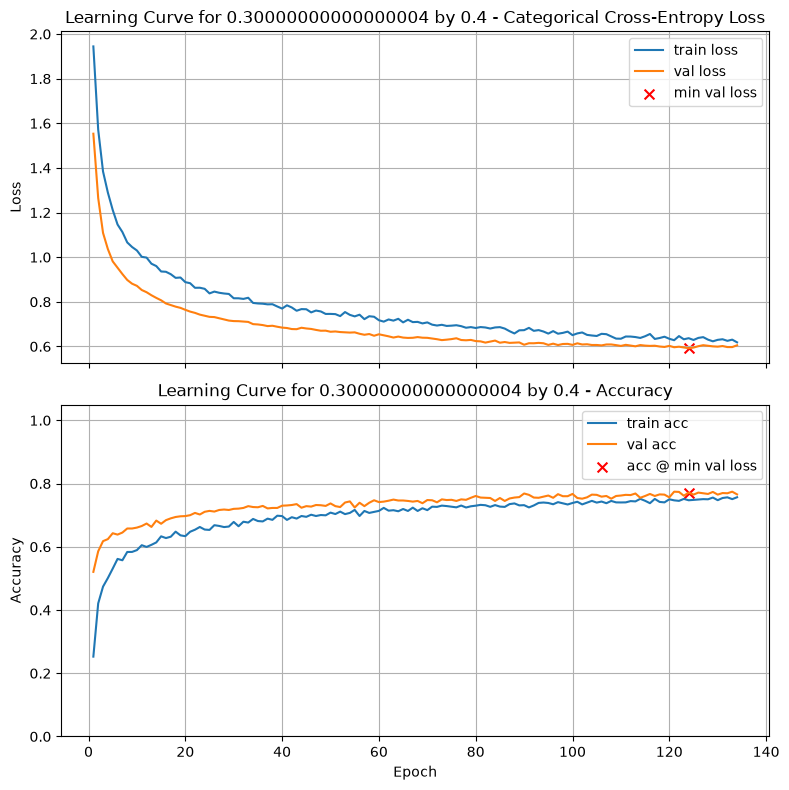

Final Training Loss:            0.6183
Final Training Accuracy:        0.7567
Final Validation Loss:          0.6052
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5920 (Epoch 124)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6131
Test Accuracy: 0.7714

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:00:28

Learning Curve for 0.4 by 0.0



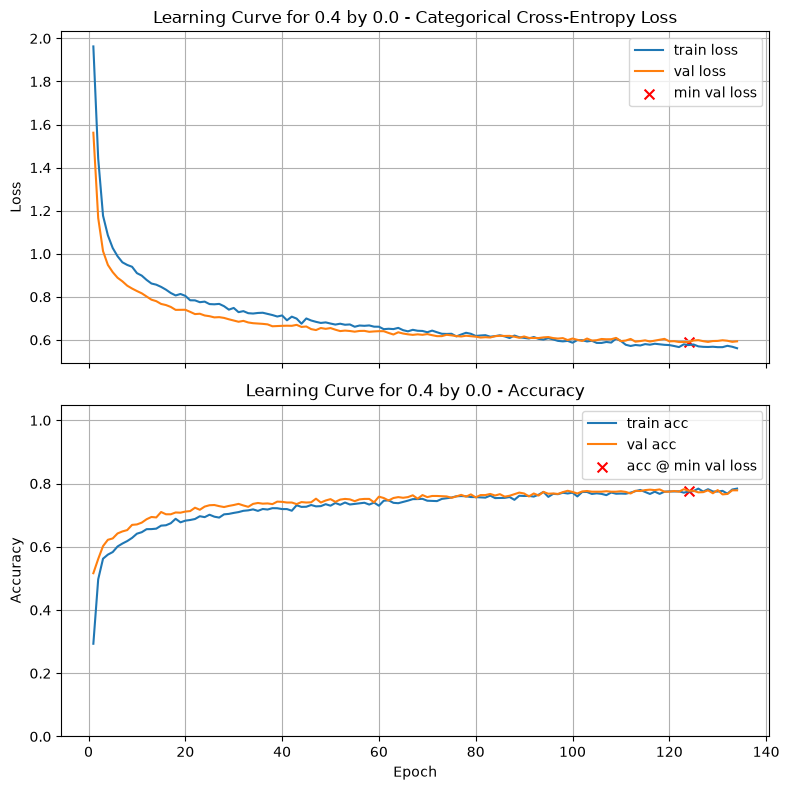

Final Training Loss:            0.5614
Final Training Accuracy:        0.7840
Final Validation Loss:          0.5934
Final Validation Accuracy:      0.7786
Minimum Validation Loss:        0.5901 (Epoch 124)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.6103
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:27

Learning Curve for 0.4 by 0.1



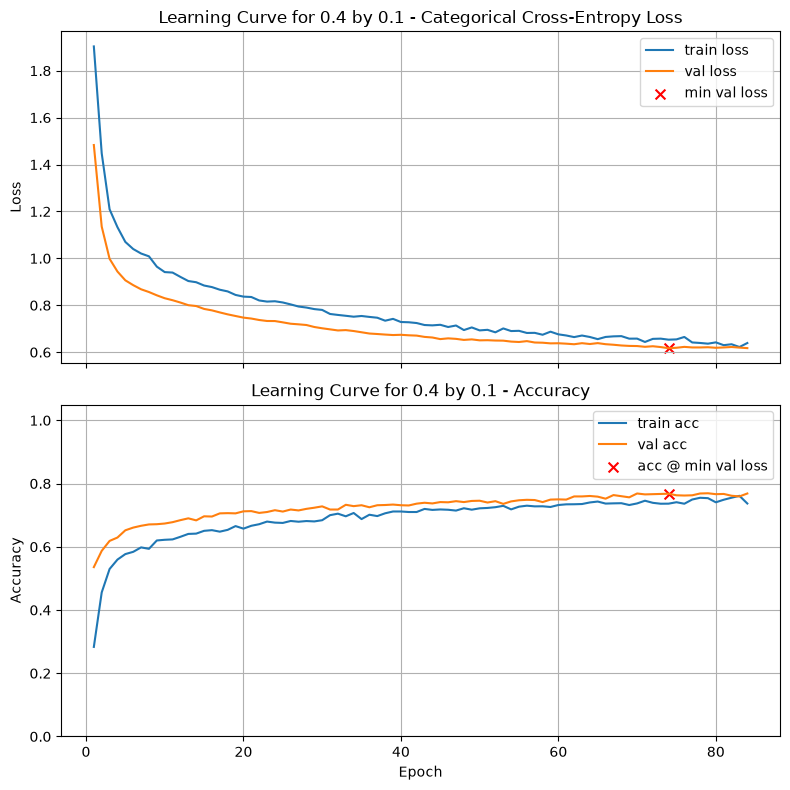

Final Training Loss:            0.6391
Final Training Accuracy:        0.7369
Final Validation Loss:          0.6174
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.6170 (Epoch 74)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6353
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:20

Learning Curve for 0.4 by 0.2



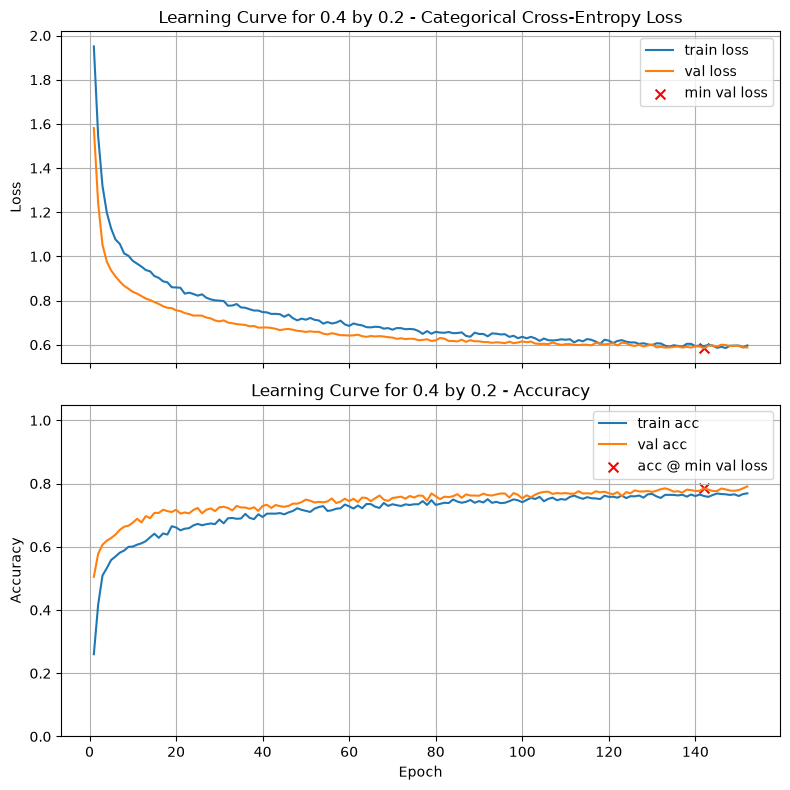

Final Training Loss:            0.5968
Final Training Accuracy:        0.7690
Final Validation Loss:          0.5880
Final Validation Accuracy:      0.7907
Minimum Validation Loss:        0.5842 (Epoch 142)
Validation Accuracy @ Min Loss: 0.7850

Test Loss: 0.6209
Test Accuracy: 0.7636

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:32

Learning Curve for 0.4 by 0.30000000000000004



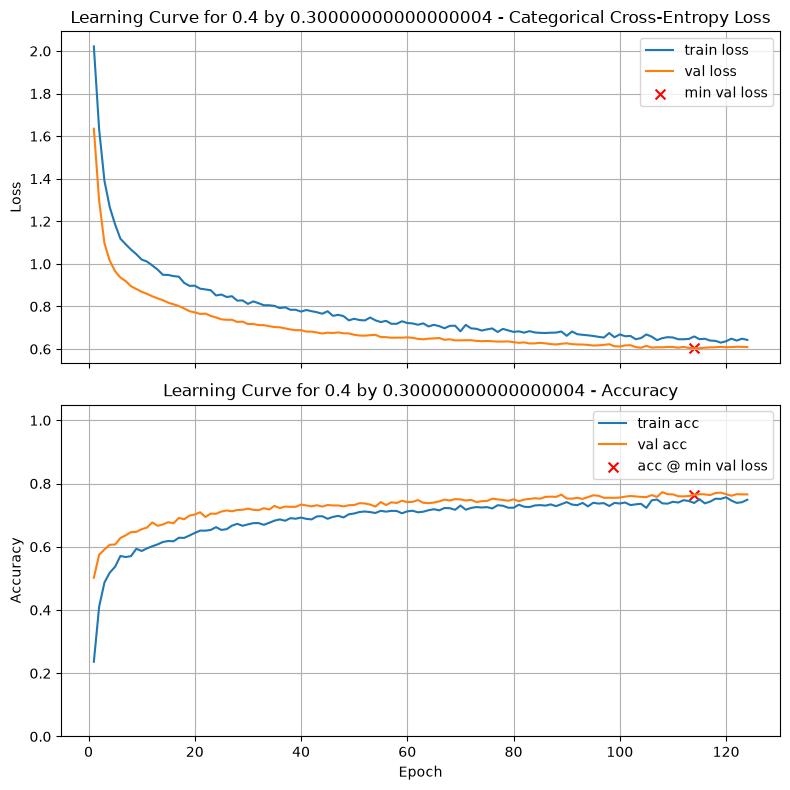

Final Training Loss:            0.6430
Final Training Accuracy:        0.7488
Final Validation Loss:          0.6092
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.6038 (Epoch 114)
Validation Accuracy @ Min Loss: 0.7643

Test Loss: 0.6412
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:41

Learning Curve for 0.4 by 0.4



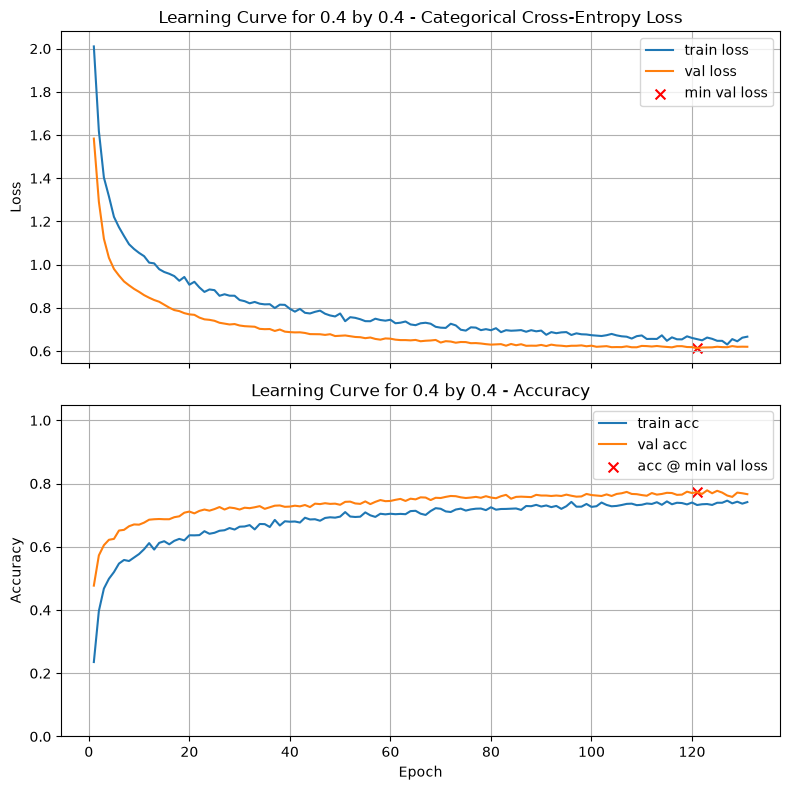

Final Training Loss:            0.6663
Final Training Accuracy:        0.7414
Final Validation Loss:          0.6195
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.6128 (Epoch 121)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6322
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:00:29


In [44]:
# Drop out rates [0-0.5]
drop_out_range = np.arange(0,0.5,0.1)
# Model with early stopping 
results_P3 = []
p3_models = []
for dropout in drop_out_range:
    for layer2_dropout in drop_out_range:    
        model_baseline = build_model(X_train.shape[1], [ (64,'relu',0.0,dropout), (32,'relu',0.001,layer2_dropout)], n_classes)
        history = train_and_test(model_baseline,title=f"Learning Curve for {dropout} by {layer2_dropout}",lr_schedule=a2a,return_history=True)
        results_P3.append(history.history['val_accuracy'])
        p3_models.append(history)



In [46]:
drop_out_rates = []
for x in drop_out_range:
    for y in drop_out_range:
        drop_out_rates.append((x,y))

p3_results = dict(zip(drop_out_rates,[max(x) for x in results_P3]))
p3_results

{(np.float64(0.0), np.float64(0.0)): 0.7671428322792053,
 (np.float64(0.0), np.float64(0.1)): 0.7842857241630554,
 (np.float64(0.0), np.float64(0.2)): 0.7842857241630554,
 (np.float64(0.0), np.float64(0.30000000000000004)): 0.7835714221000671,
 (np.float64(0.0), np.float64(0.4)): 0.7850000262260437,
 (np.float64(0.1), np.float64(0.0)): 0.7871428728103638,
 (np.float64(0.1), np.float64(0.1)): 0.7914285659790039,
 (np.float64(0.1), np.float64(0.2)): 0.7764285802841187,
 (np.float64(0.1), np.float64(0.30000000000000004)): 0.7871428728103638,
 (np.float64(0.1), np.float64(0.4)): 0.772857129573822,
 (np.float64(0.2), np.float64(0.0)): 0.7785714268684387,
 (np.float64(0.2), np.float64(0.1)): 0.7971428632736206,
 (np.float64(0.2), np.float64(0.2)): 0.793571412563324,
 (np.float64(0.2), np.float64(0.30000000000000004)): 0.7850000262260437,
 (np.float64(0.2), np.float64(0.4)): 0.7828571200370789,
 (np.float64(0.30000000000000004), np.float64(0.0)): 0.7900000214576721,
 (np.float64(0.30000000000

In [49]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = max(p3_results,key=p3_results.get)#(0.0,0.0)             # Replace (0.0,0.0) with your answer

In [50]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (np.float64(0.2), np.float64(0.1))


In [51]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = p3_results[a3a]             # Replace 0.0 with your answer

In [52]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7971


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simply by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


In [24]:
# Your code here. Add as many cells as you need. 


In [25]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (0.0,0.0)             # Replace (0.0,0.0) with your answer

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0, 0.0)


In [27]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.0             # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.0000


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



In [29]:
# Your code here. Add as many cells as you need.


In [30]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.0             # Replace 0.0 with your answer

In [31]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.0000


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.


In [32]:
# Your code here


In [33]:
# Set a6 to the validation accuracy found by this best model

a6 = 0.0             # Replace 0.0 with your answer

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.0000


### Optional: Print out your results of all experiments

In [35]:
print_results()

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?